# 01 · Baseline: standard (Euler) residual transformer, 20M params, 50M tokens

1. Build the model and count parameters.
2. Search for the largest batch that fits, then **fix** the batch size to the largest power of two at or below it. Runs 01 and 02 both use this batch size.
3. Train for 50M tokens and save loss, tokens/s and peak memory to `results/baseline.json`.

In [1]:
# --- Colab setup: GPU runtime (Runtime > Change runtime type > T4 GPU) ---
REPO_URL = "https://github.com/gaurkhare/gaurav-eagv5-s13.git"
import os, sys, json
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    WORK = "/content/drive/MyDrive/era_a13"          # data + results persist across notebooks
    if not os.path.exists("/content/repo"):
        !git clone -q {REPO_URL} /content/repo
    os.chdir("/content/repo")
else:
    WORK = os.path.abspath("..")                      # running locally from notebooks/
    os.chdir(WORK)
sys.path.insert(0, os.getcwd())
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
DATA_DIR, RESULTS = f"{WORK}/data", f"{WORK}/results"
os.makedirs(RESULTS, exist_ok=True)
!nvidia-smi --query-gpu=name,memory.total --format=csv 2>/dev/null || echo "no nvidia GPU"

Mounted at /content/drive
name, memory.total [MiB]
Tesla T4, 15360 MiB


In [2]:
import torch
from revllm import LLM, ModelConfig, TrainConfig, train, find_max_batch
mcfg = ModelConfig(residual="euler")
m = LLM(mcfg)
print(m)
print(f"params: {m.num_params():,}  (embedding, tied: {m.embed.weight.numel():,})")
del m

LLM(
  (embed): Embedding(32000, 320)
  (blocks): ModuleList(
    (0-7): 8 x Block(
      (attn): Attention(
        (norm): RMSNorm((320,), eps=None, elementwise_affine=True)
        (qkv): Linear(in_features=320, out_features=960, bias=False)
        (proj): Linear(in_features=320, out_features=320, bias=False)
      )
      (mlp): MLP(
        (norm): RMSNorm((320,), eps=None, elementwise_affine=True)
        (gate_up): Linear(in_features=320, out_features=1728, bias=False)
        (down): Linear(in_features=864, out_features=320, bias=False)
      )
    )
  )
  (norm): RMSNorm((320,), eps=None, elementwise_affine=True)
  (lm_head): Linear(in_features=320, out_features=32000, bias=False)
)
params: 20,157,760  (embedding, tied: 10,240,000)


## Find the batch size the baseline can run

In [3]:
bmax, trials = find_max_batch(mcfg, start=8)
B_FIXED = 1 << (bmax.bit_length() - 1)             # largest power of two <= max
print(f"baseline max batch = {bmax}; fixed batch for runs 01/02 = {B_FIXED} ({B_FIXED*mcfg.seq_len:,} tokens/step)")
json.dump({"baseline_max_batch": bmax, "fixed_batch": B_FIXED, "trials": trials}, open(f"{RESULTS}/batch.json", "w"), indent=1)

  B=   16: ok  peak 3.35 GB
  B=   32: ok  peak 4.93 GB
  B=   64: ok  peak 8.10 GB
  B=  128: OOM
  B=   96: ok  peak 11.27 GB
  B=  112: ok  peak 12.85 GB
  B=  120: ok  peak 13.65 GB
baseline max batch = 120; fixed batch for runs 01/02 = 64 (32,768 tokens/step)


## Train

In [4]:
cfg = TrainConfig(name="baseline", data_dir=DATA_DIR, out_dir=RESULTS, batch_size=B_FIXED,
                  total_tokens=50_000_000, lr=1e-3, model=mcfg)
res, model = train(cfg)

[baseline] device=cuda amp=torch.bfloat16 params=20.16M residual=euler B=64 T=512 steps=1525 tokens=50.0M lr=0.001
step   100/1525 loss 6.2045 (ema 7.5864) lr 9.95e-04 gnorm 0.41 11.8k tok/s peak 8.10 GB
step   200/1525 loss 5.4989 (ema 6.8324) lr 9.72e-04 gnorm 0.45 11.8k tok/s peak 8.10 GB
  eval @ 250: val_loss 5.3481
step   300/1525 loss 5.1646 (ema 6.2083) lr 9.30e-04 gnorm 0.50 11.8k tok/s peak 8.10 GB
step   400/1525 loss 4.9372 (ema 5.7158) lr 8.71e-04 gnorm 0.51 11.8k tok/s peak 8.10 GB
step   500/1525 loss 4.7327 (ema 5.3396) lr 7.99e-04 gnorm 0.42 11.8k tok/s peak 8.10 GB
  eval @ 500: val_loss 4.7544
step   600/1525 loss 4.5686 (ema 5.0598) lr 7.15e-04 gnorm 0.45 11.8k tok/s peak 8.10 GB
step   700/1525 loss 4.5826 (ema 4.8829) lr 6.24e-04 gnorm 0.44 11.8k tok/s peak 8.10 GB
  eval @ 750: val_loss 4.4779
step   800/1525 loss 4.5275 (ema 4.7235) lr 5.30e-04 gnorm 0.47 11.8k tok/s peak 8.10 GB
step   900/1525 loss 4.3949 (ema 4.5998) lr 4.36e-04 gnorm 0.46 11.8k tok/s peak 8.

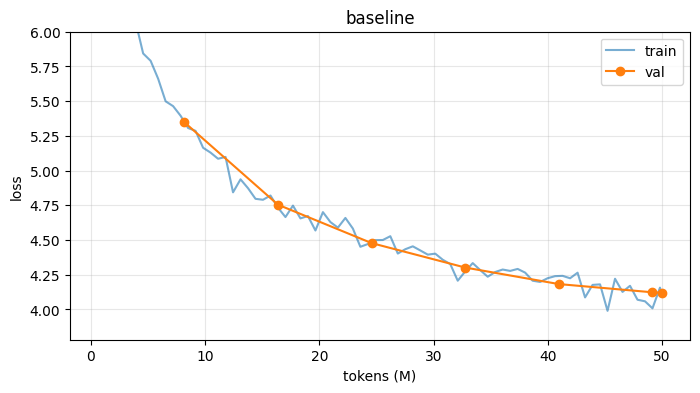

{'final_train_loss': 4.089612642923991,
 'final_val_loss': 4.120518755912781,
 'tokens_per_s': 11782.053476709414,
 'peak_mem_allocated_gb': 8.099800109863281,
 'peak_mem_reserved_gb': 8.580078125,
 'wall_time_min': 72.08326286474863,
 'gpu': 'Tesla T4'}

In [5]:
import matplotlib.pyplot as plt
h = res["history"]; e = res["evals"]
plt.figure(figsize=(8, 4))
plt.plot([r["tokens"]/1e6 for r in h], [r["loss"] for r in h], label="train", alpha=.6)
plt.plot([r["tokens"]/1e6 for r in e], [r["val_loss"] for r in e], "o-", label="val")
plt.xlabel("tokens (M)"); plt.ylabel("loss"); plt.ylim(top=6); plt.legend(); plt.grid(alpha=.3); plt.title("baseline")
plt.show()
{k: res[k] for k in ["final_train_loss", "final_val_loss", "tokens_per_s", "peak_mem_allocated_gb", "peak_mem_reserved_gb", "wall_time_min", "gpu"]}

In [6]:
# sample generation (sanity check)
from transformers import AutoTokenizer
from revllm.data import TOKENIZER
tok = AutoTokenizer.from_pretrained(TOKENIZER)
@torch.no_grad()
def generate(model, prompt, n=60, temp=0.8):
    model.eval(); dev = next(model.parameters()).device
    x = torch.tensor([tok(prompt)["input_ids"]], device=dev)
    for _ in range(n):
        logits = model(x[:, -mcfg.seq_len:])[:, -1] / temp
        x = torch.cat([x, torch.multinomial(logits.float().softmax(-1), 1)], 1)
    return tok.decode(x[0])
print(generate(model, "The water cycle is"))

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.29k [00:00<?, ?B/s]

tokenizer.model: reconstructing file:   0%|          |  0.00B /  500kB            

tokenizer.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

<s> The water cycle is 100 percent easier because the water temperatures are 10 percent lower.
The water system for water is water quality, and water pills are adequately water quality and often switch the water level. The water quality muscle is not suitable for all things, and safety can
